# 🛒 Sales Data Analysis using Python

### Objective
This project analyzes sales data to uncover business insights using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn.
    The analysis focuses on customer behavior, product performance, sales trends, and profitability to support business decision-making.

## Project Workflow

Import Libraries
      ↓
Load Dataset
      ↓
Data Cleaning
      ↓
Descriptive Statistics
      ↓
EDA
      ↓
Business Insights
      ↓
Recommendations
      ↓
Conclusion

## 📚 Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Loading the Dataset

In [3]:
pd.set_option("display.max_columns",None)
df = pd.read_csv("SampleSuperstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 🔍 Exploring the Dataset

Understanding the structure, dimensions, and summary statistics of the dataset before analysis.

In [4]:
df.shape

(9994, 13)

In [5]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [7]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.shape

(9994, 13)

In [9]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

## 🧹 Data Cleaning

Cleaning the dataset by handling missing values, duplicates, and formatting issues to ensure accurate analysis.

In [10]:
df.duplicated().sum()

np.int64(17)

In [11]:
df.drop_duplicates(inplace=True)

### Key Statistical Measures

In [12]:
stats = pd.DataFrame({
    "Sum": df[["Sales","Profit"]].sum(),
    "Mean": df[["Sales","Profit"]].mean(),
    "Maximum": df[["Sales","Profit"]].max(),
    "Minimum": df[["Sales","Profit"]].min()
})

stats

,Sum,Mean,Maximum,Minimum
Sales,2.296196e+06,230.148902,22638.480,0.444
Profit,2.862414e+05,28.690130,8399.976,-6599.978


# 📊 Exploratory Data Analysis (EDA)

Visualizing the data to identify trends, patterns, and relationships among different business variables.

# Region with highest sales

In [26]:
df.groupby("Region")["Sales"].sum().sort_values(ascending = False)

Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64

### Region with highest profit


In [27]:
df.groupby("Region")["Profit"].sum().sort_values(ascending = False)

Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64

# State with highest profit


In [28]:
df.groupby("State")["Profit"].sum().sort_values(ascending = False).head(10)

State
California    76330.7891
New York      74015.4622
Washington    33368.2375
Michigan      24428.0903
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

# State that causing losses


In [30]:
df.groupby("State")["Profit"].sum().sort_values(ascending = False)

State
California              76330.7891
New York                74015.4622
Washington              33368.2375
Michigan                24428.0903
Virginia                18597.9504
Indiana                 18382.9363
Georgia                 16250.0433
Kentucky                11199.6966
Minnesota               10823.1874
Delaware                 9977.3748
New Jersey               9772.9138
Wisconsin                8401.8004
Rhode Island             7285.6293
Maryland                 7031.1788
Massachusetts            6785.5016
Missouri                 6436.2105
Alabama                  5786.8253
Oklahoma                 4853.9560
Arkansas                 4008.6871
Connecticut              3511.4918
Nevada                   3316.7659
Mississippi              3172.9762
Utah                     2546.5335
Vermont                  2244.9783
Louisiana                2196.1023
Nebraska                 2037.0942
Montana                  1833.3285
South Carolina           1769.0566
New Hampshire 

### Category that earns highest profit

In [32]:
#category earns highest profit
df.groupby("Category")["Profit"].sum()

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64

### The following visualizations provide business insights into sales, profit, discounts, customer segments, and regional performance.

### 1. Sales Distribution

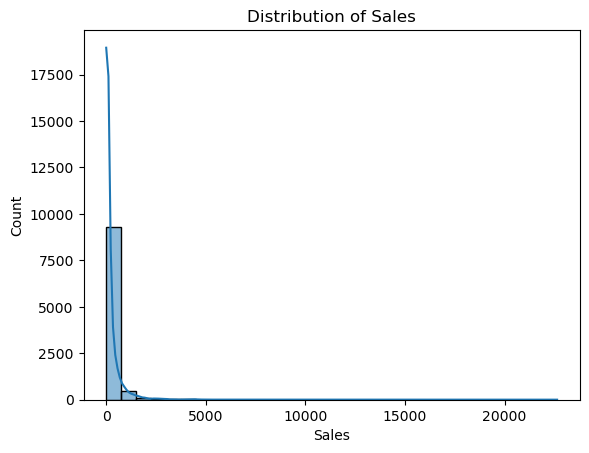

In [69]:
#sales distribution
sns.histplot(df["Sales"],bins=30,kde=True)
plt.title("Distribution of Sales")
plt.show()

### Business Insight
- Most order have relatively low sales values.
- A few orders have very high sales,creating a right-skewed distribution.
- The business receives many small-value orders and only a limited of high value transactions.

### 2. Profit Distribution

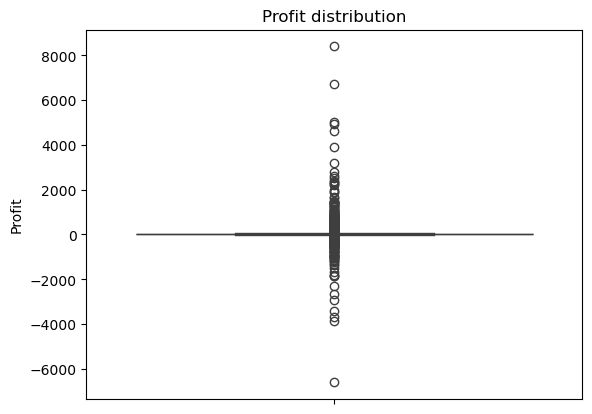

In [71]:
sns.boxplot(df["Profit"])
plt.title("Profit distribution")
plt.show()

### 3. Sales by category

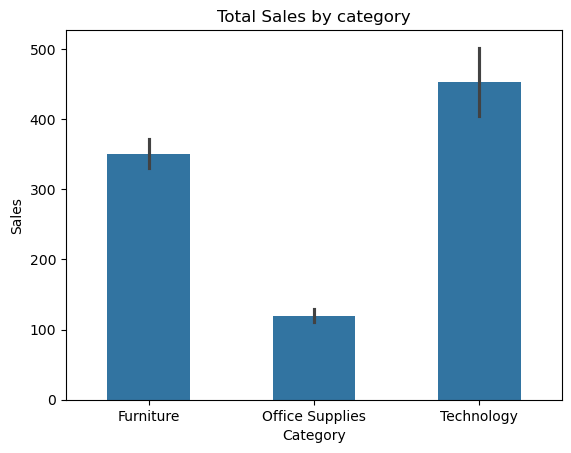

In [15]:
sns.barplot(x="Category", y = "Sales", data = df,width = 0.5)
plt.title("Total Sales by category")
plt.show()

### Business Insight
- Technology generates the maximum Sales.
- Office Supplies contributes consistent sales .
- Furniture has lower sales compared to technology.


### 4. Profit by Category

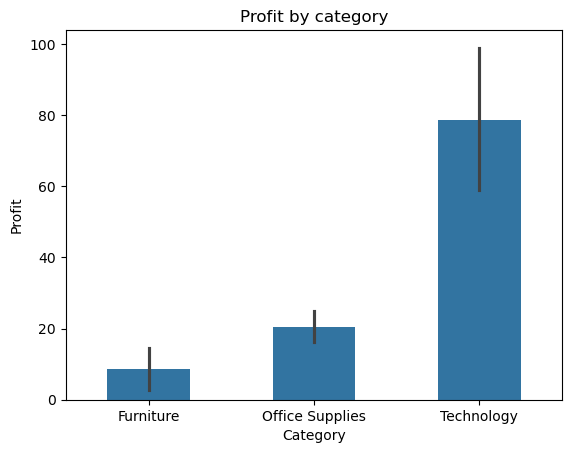

In [58]:
sns.barplot(x="Category", y = "Profit", data = df,width = 0.5)
plt.title("Profit by category")
plt.show()

### Business Insight
- Technology generates the maximum Profit.
- Furniture contributes consistent profit .
- office Supplies category has less profit compared to technology.


### 5. Sales by Region

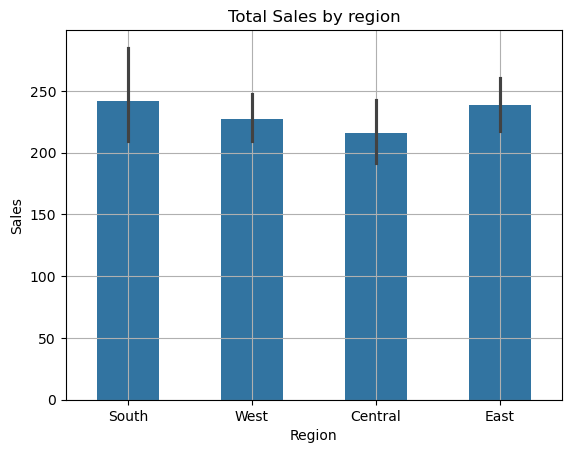

In [16]:
sns.barplot(x="Region", y = "Sales", data = df,width = 0.5)
plt.title("Total Sales by region")
plt.grid(True)
plt.show()

### Business Insight

- The West region generated the highest sales, making it the strongest-performing market.
- The South region contributed the lowest sales, indicating opportunities for market expansion.
- The company can analyze successful strategies used in the West and implement them in lower-performing regions.

### 6. Profit by States

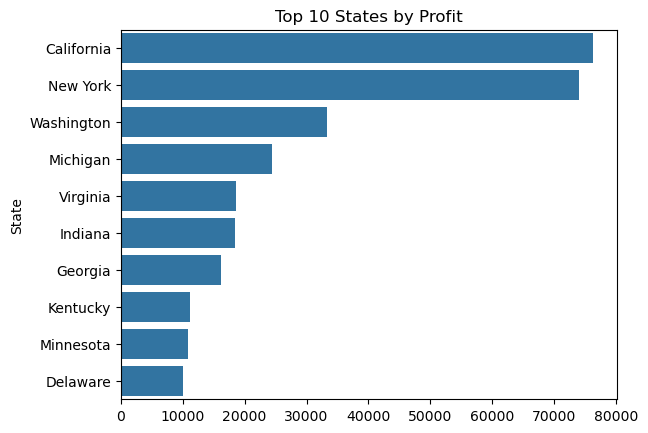

In [19]:
top_states = df.groupby("State")["Profit"].sum().sort_values(ascending = False).head(10)
sns.barplot(x=top_states.values,y=top_states.index)
plt.title("Top 10 States by Profit")
plt.show()

### Business Insight
- Califorina shows the maximum prifit rate.

### 7. Discount vs Profit

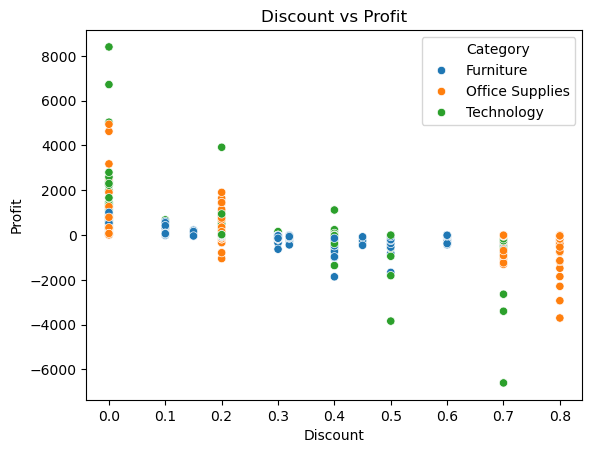

In [74]:
sns.scatterplot(data = df , x = "Discount",y ="Profit",hue = "Category")
plt.title("Discount vs Profit")
plt.show()

### Business Insight

- Higher discounts generally lead to lower profits.
- Orders with excessive discounts often result in minimal or even negative profit.
- The company should review its discount policy to avoid unnecessary revenue loss while maintaining customer satisfaction.

### 8. Category-wise Sales Distribution

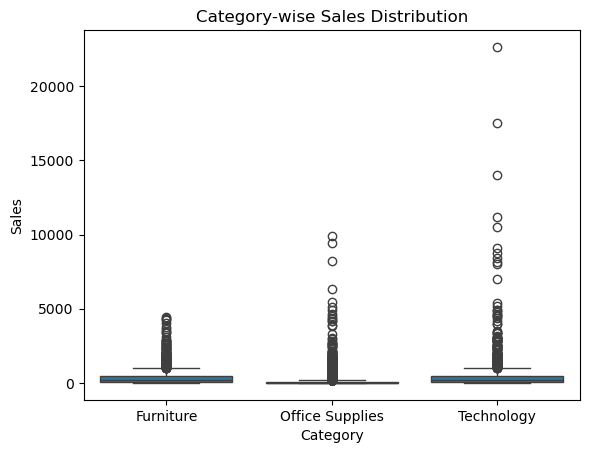

In [14]:
sns.boxplot(data = df, x = "Category",y ="Sales")
plt.title("Category-wise Sales Distribution")
plt.show()

### Business Insight
- Technology generates the highest sales revenue.
- Furniture and Office Supplies contribute lower sales.
- The company should continue investing in high-demand technology products.

### 9. Correlation Heatmap

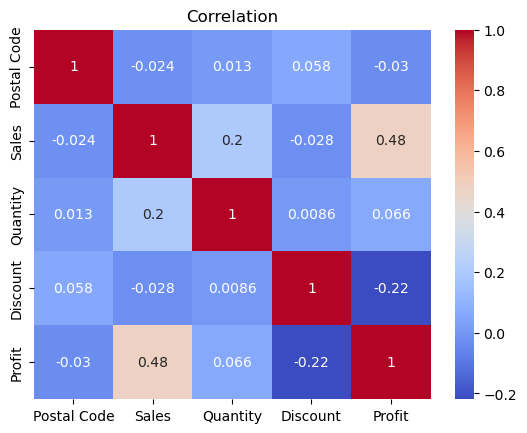

In [84]:
#Heat map
df = pd.read_csv("SampleSuperstore.csv")
df.head()
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot =True,cmap = "coolwarm")
plt.title("Correlation")
plt.show()

### Business Insight
- Sales and profit are moderately positively correlated, showing that higher sales usually improve profit.
- Discount negatively affects profit, so excessive discount should be controlled.
- Quantity has a weak relationship with Sales and almost no effect on profit.
- Postal Code does not show any meaningful business relationship.

### 10. Average Discount by Category

C:\Users\mohan\AppData\Local\Temp\ipykernel_8220\1803959358.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=discount.index,


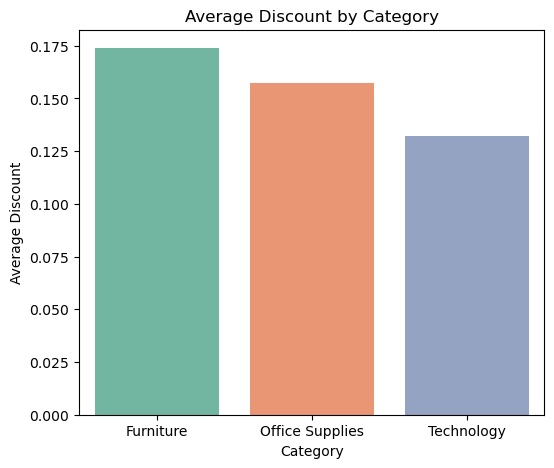

In [100]:
discount = df.groupby('Category')['Discount'].mean()

plt.figure(figsize=(6,5))
sns.barplot(x=discount.index,
            y=discount.values, 
            palette='Set2')

plt.title("Average Discount by Category")
plt.ylabel("Average Discount")
plt.show()

### Business Insight
- Maximum rate of discount is available on Furniture.

# Key Findings

• Technology category contributes significantly to total sales.

• West region generated higher sales compared to other regions.

• Discounts reduce profitability.

• Sales and Profit have a moderate positive correlation.

• Some products generate high revenue but comparatively low profit.

• Sales distribution is positively skewed due to a few very large orders.

### Summary
summary = pd.DataFrame({
    "Metric": ["Total Sales", "Total Profit", "Average Discount"],
    "Value": [
        df["Sales"].sum(),
        df["Profit"].sum(),
        df["Discount"].mean()
    ]
})



# 📈 Business Recommendations

- Increase inventory for high-performing products during peak seasons.
- Review discount strategies for low-profit sub-categories.
- Focus marketing efforts on high-value customers.
- Improve sales in underperforming regions through targeted campaigns.
- Expand profitable product categories while minimizing losses from low-performing products.

# ✅ Conclusion

This analysis provided valuable insights into sales performance, customer purchasing behavior, regional trends, and profitability. The findings can help businesses optimize inventory planning, pricing strategies, customer targeting, and overall decision-making to improve revenue and profitability.